## Essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

## Data input

In [16]:
df = pd.read_csv('data/archive/spam.csv', encoding='ISO-8859-1')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [18]:
df['v2'] = df['v2'] \
        + " " + df['Unnamed: 2'].fillna('') \
        + " " + df['Unnamed: 3'].fillna('') \
        + " " + df['Unnamed: 4'].fillna('')

In [19]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [20]:
df = df.drop_duplicates(keep='first')
df.head(10)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [30]:
ham_msgs = df[df['v1'] == 'ham']['v2']
spam_msgs = df[df['v1'] == 'spam']['v2']

## Data exploration

In [23]:
from wordcloud import WordCloud

In [31]:
ham_text = " ".join(ham_msgs)
spam_text = " ".join(spam_msgs)

In [25]:
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(ham_text)

### Ham word cloud

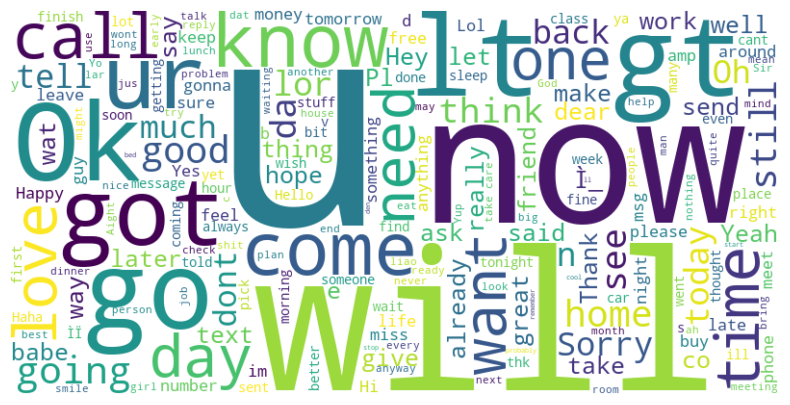

In [26]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [32]:
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(spam_text)

### Spam word cloud

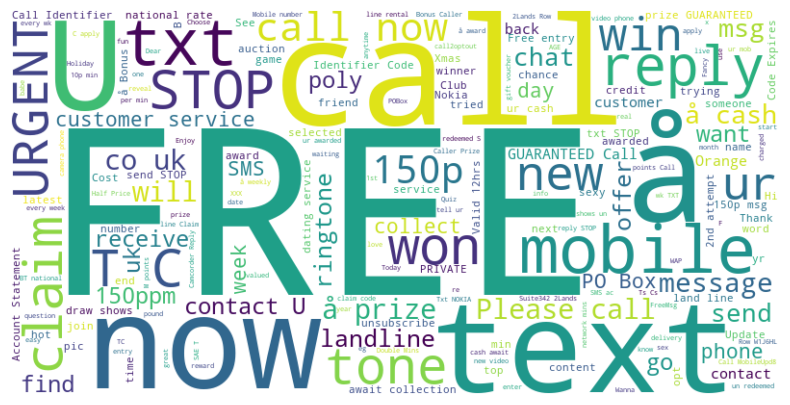

In [33]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Lemmetization and removing stop words

In [34]:
import spacy

In [36]:
nlp = spacy.load('en_core_web_sm')

In [37]:
def preprocess_spacy(text):
    doc = nlp(text)
    words = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(words)

In [38]:
lemmatized_ham = preprocess_spacy(ham_text)

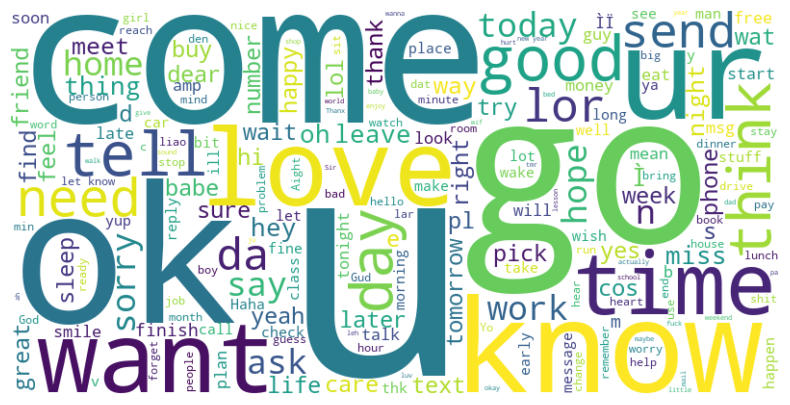

In [39]:
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(lemmatized_ham)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [40]:
lemmatized_spam = preprocess_spacy(spam_text)

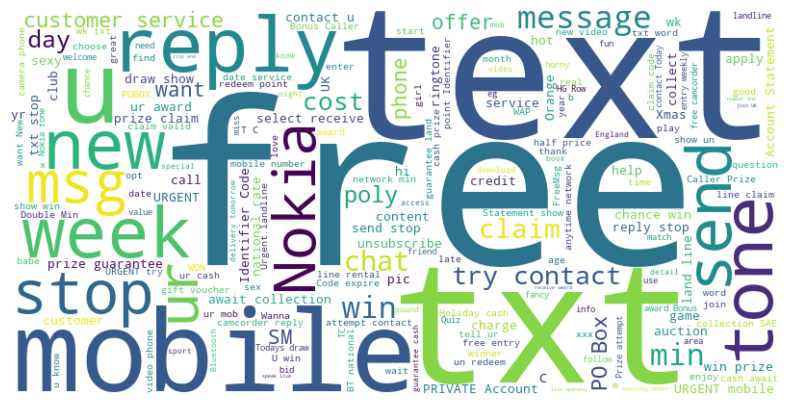

In [42]:
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(lemmatized_spam)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### N gram word count

In [44]:
words_1_gram_ham = pd.DataFrame(lemmatized_ham.split(' '), columns=['1_gram_ham']).value_counts()
words_1_gram_spam = pd.DataFrame(lemmatized_spam.split(' '), columns=['1_gram_spam']).value_counts()

In [51]:
words_1_gram_ham.values

array([765, 309, 296, ...,   1,   1,   1], dtype=int64)

In [ ]:
from nltk import ngrams

words_1_gram_ham = pd.DataFrame(lemmatized_ham.split(' '), columns=['1_gram_ham']).value_counts()
words_1_gram_spam = pd.DataFrame(lemmatized_spam.split(' '), columns=['1_gram_spam']).value_counts()

In [52]:
words_1_gram_ham_word = [word[0] for word in words_1_gram_ham.index]
words_1_gram_ham_count = words_1_gram_ham.values

In [55]:
plt.bar(words_1_gram_ham_word, words_1_gram_ham_count)
plt.title('Ham word count')
plt.show()

KeyboardInterrupt: 

## Preprocessing

In [17]:
# Converting label to 1(ham) or 0(spam)
label = [1 if i == 'ham' else 0 for i in label_class]
messages = [message.lower() for message in messages]

### Stopword removal

In [103]:
stopword_path = './nltk_download/corpora/stopwords/english'
stops = set(stopwords.words('english'))
print(stops)

OSError: No such file or directory: 'C:\\Users\\Aamir Sahil\\AppData\\Roaming\\nltk_data\\corpora\\stopwords\\english'

In [63]:
# replace stop words by <stpw> and punctuations by <punct>
def replace_stopwords(words):
    stops = set(stopwords.words('english'))
    words = [word if word in stops else "<stpw>" for word in words]
    return words
def replace_punctuations(text):
    modified_text = ''
    return modified_text

In [72]:
text = "hi, i feel very good by the way"
words = word_tokenize(text)
words

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\Aamir Sahil/nltk_data'
    - 'd:\\Coding\\spam-filter\\spam-ham\\env\\nltk_data'
    - 'd:\\Coding\\spam-filter\\spam-ham\\env\\share\\nltk_data'
    - 'd:\\Coding\\spam-filter\\spam-ham\\env\\lib\\nltk_data'
    - 'C:\\Users\\Aamir Sahil\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
messages_tokenized = [word_tokenize(message) for message in messages]
messages_tokenized = [replace_stopwords(words) for words in messages_tokenized]
messages_tokenized = [replace_punctuations(words) for words in messages_tokenized]

### Stemming

### Tokenization

## Vectorization

### Bag of word

### TF-IDF

### Word2Vec

## Model

### SVM

#### Training

#### Testing

### Neural Network

#### Training

#### Testing

### Naive Bayes

#### Training

#### Testing

## Test

In [18]:
import nltk
from nltk.stem import PorterStemmer
import re

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
df = pd.read_csv('data/archive/spam.csv', encoding='ISO-8859-1')

In [22]:
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [24]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [25]:
df = df.drop_duplicates(keep='first')

In [26]:
df.shape

(5169, 5)

In [27]:
label = df.v1.to_list()
messages = df.v2.to_list()

In [28]:
porter_stemmer = PorterStemmer()

In [59]:
text = "All in all it was a great journey"
text = text.lower()
text = re.sub("\W", " ", text)
text = re.sub("\s+(all|the|in|for|and|on)\s+"," _connector_ ",text)
words=re.split("\s+",text)
stemmed_words=[porter_stemmer.stem(word=word) for word in words]

In [60]:
stemmed_words

['all', '_connector_', 'all', 'it', 'wa', 'a', 'great', 'journey']

In [47]:
stemed_words = [porter_stemmer.stem(word=word) for word in words]

In [48]:
stemed_words

['all_coonector_al', 'it', 'wa', 'a', 'great', 'journey']

In [17]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub("\W", " ", text)
    text=re.sub("\s+(in|the|all|for|and|on)\s+"," _connector_ ",text)
    words=re.split("\s+",text)
    stemmed_words=[porter_stemmer.stem(word=word) for word in words]
    return ' '.join(stemmed_words)

In [18]:
def tokenizer(text):
    text = re.sub("(\W)", "\1 ", text)
    return re.split("\s+", text)

In [19]:
vectorizer = CountVectorizer(tokenizer=tokenizer, ngram_range=(1,2), min_df=0.006, preprocessor=preprocess_text)
x = vectorizer.fit_transform(messages)

d:\Coding\spam-filter\spam-ham\env\lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [25]:
x.toarray()

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [ ]:
sns.countplot(df['v1'])

In [ ]:
from imblearn.under_sampling import NearMiss
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

In [ ]:
ros = RandomOverSampler(random_state = 42)
print('Original dataset shape', Counter(label))

In [ ]:
x, y = ros.fit_resample(messages, label)
print('Original dataset shape', Counter(y))

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [ ]:
clf = MultinomialNB()
clf.fit(x, y)

In [ ]:
y_predNB = clf.predict(x_test)
NB_Acc = clf.score(y_test, y_predNB)
print(NB_Acc)

In [ ]:
cm = confusion_matrix(y_test, y_predNB)
sns.heatmap(cm, annot=True, fmt='d')